# Project 2: Unsupervised Learning from LPBF Anomaly Features

In this mini project, we use **unsupervised learning** to group printed parts based on their in-situ anomaly patterns.

For this, we keep only the **60 fatigue-tested parts**. This avoids confusion from extra process parameters that do not have fatigue-life results.

Main idea:

> Can printed parts be grouped based only on anomaly behavior, without using fatigue-life labels during training?

Post-hoc interpretation:

> After clustering, do the discovered anomaly groups relate to process parameters or fatigue-life class?


## Important idea: What is an anomaly?

In this dataset, an **anomaly** is an unusual pattern detected during laser powder bed fusion (LPBF) printing.

For this beginner project, we focus on selected anomaly types:

- **Recoater streaking:** marks caused by recoater/powder spreading issues  
- **Spatter:** particles ejected onto the powder bed  
- **Over melting:** regions associated with excessive local energy input  
- **Bright spot:** localized bright/hot region in the image data  
- **Pitting:** small pit-like surface marks after recoating  

These anomaly values are stored as **fractions** for each printed part.  
For example, if `over_melting = 0.75`, that means 75% of the selected anomaly pixels for that part were labeled as over melting.

## 1. Mount Google Drive

Run this cell if you are using Google Colab.  
Make sure the CSV file is uploaded to your Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Set the CSV file path

Expected file name:

`project2_unsupervised_with_posthoc_labels.csv`

This single CSV contains anomaly-feature columns and post-hoc columns.

In this notebook, we will keep only rows with available fatigue-life labels, giving **60 fatigue-tested parts**.

In [2]:
# TODO: Change this path to match your Google Drive folder

csv_path = "/content/drive/MyDrive/Colab_Notebooks/SUPREME_2026/Project_02/project2_unsupervised_with_posthoc_labels.csv"

## 3. Import libraries and load the dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_all = pd.read_csv(csv_path)

print("Original dataset loaded successfully!")
print("Original shape:", df_all.shape)
display(df_all.head())

# ------------------------------------------------------------
# Keep only the 60 fatigue-tested parts
# ------------------------------------------------------------
# Some parts in the full anomaly-feature dataset do not have fatigue-life results.
# For this project, we keep only parts with log10_fatigue_life available.

if "log10_fatigue_life" in df_all.columns:
    df = df_all.dropna(subset=["log10_fatigue_life"]).copy().reset_index(drop=True)
else:
    raise ValueError("The dataset must include a 'log10_fatigue_life' column for this final version.")

print("\nAfter keeping only fatigue-tested parts:")
print("Shape:", df.shape)
print("Number of unique parts:", df["part_id"].nunique())

display(df.head())


Original dataset loaded successfully!
Original shape: (67, 17)


,part_id,recoater_streaking,incomplete_spreading,spatter,swelling,over_melting,bright_spot,pitting,parameter_set,power,scan_speed,hatch_spacing,ved,overall_quality,log10_fatigue_life,life_class,life_class_name
0,1,0.109565,0.000008,0.015224,0.007506,0.812550,0.037202,0.017944,0,255.0,188.0,200.0,67.8,2.0,NaN,NaN,NaN
1,2,0.113983,0.000056,0.079001,0.007600,0.758372,0.030992,0.009995,2,400.0,600.0,75.0,88.9,2.0,4.180699,0.0,Short life
2,3,0.791582,0.000001,0.169361,0.003382,0.000000,0.018874,0.016800,1,370.0,800.0,100.0,46.3,0.0,5.530749,1.0,Long life
3,4,0.812493,0.000000,0.152968,0.003136,0.000000,0.012357,0.019046,1,370.0,800.0,100.0,46.3,0.0,4.869877,0.0,Short life
4,5,0.765535,0.000000,0.192272,0.004514,0.000000,0.015069,0.022610,1,370.0,800.0,100.0,46.3,0.0,5.593806,1.0,Long life



After keeping only fatigue-tested parts:
Shape: (60, 17)
Number of unique parts: 60


,part_id,recoater_streaking,incomplete_spreading,spatter,swelling,over_melting,bright_spot,pitting,parameter_set,power,scan_speed,hatch_spacing,ved,overall_quality,log10_fatigue_life,life_class,life_class_name
0,2,0.113983,0.000056,0.079001,0.007600,0.758372,0.030992,0.009995,2,400.0,600.0,75.0,88.9,2.0,4.180699,0.0,Short life
1,3,0.791582,0.000001,0.169361,0.003382,0.000000,0.018874,0.016800,1,370.0,800.0,100.0,46.3,0.0,5.530749,1.0,Long life
2,4,0.812493,0.000000,0.152968,0.003136,0.000000,0.012357,0.019046,1,370.0,800.0,100.0,46.3,0.0,4.869877,0.0,Short life
3,5,0.765535,0.000000,0.192272,0.004514,0.000000,0.015069,0.022610,1,370.0,800.0,100.0,46.3,0.0,5.593806,1.0,Long life
4,6,0.777960,0.000000,0.175218,0.004686,0.000000,0.016918,0.025218,1,370.0,800.0,100.0,46.3,0.0,4.859378,0.0,Short life


## 4. Understand the dataset

This notebook uses only the **60 fatigue-tested parts**.

The dataset has two types of columns.

### Columns used for unsupervised learning

These are the only columns we use for PCA and K-means:

- `recoater_streaking`
- `incomplete_spreading`
- `spatter`
- `swelling`
- `over_melting`
- `bright_spot`
- `pitting`

### Columns used only after clustering

These are used for interpretation, not for training:

- `parameter_set`
- `ved`
- `log10_fatigue_life`
- `life_class_name`

Important: PCA and K-means do **not** use the fatigue-life labels. Labels are used only after clustering.

In [25]:
print("Columns:")
for col in df.columns:
    print("-", col)

print("\nMissing values:")
display(df.isna().sum())

print("\nSummary statistics:")
display(df.describe())

Columns:
- part_id
- recoater_streaking
- incomplete_spreading
- spatter
- swelling
- over_melting
- bright_spot
- pitting
- parameter_set
- power
- scan_speed
- hatch_spacing
- ved
- overall_quality
- log10_fatigue_life
- life_class
- life_class_name
- fraction_sum
- PCA1
- PCA2
- cluster

Missing values:


,0
part_id,0
recoater_streaking,0
incomplete_spreading,0
spatter,0
swelling,0
over_melting,0
bright_spot,0
pitting,0
parameter_set,0
power,0



Summary statistics:


,part_id,recoater_streaking,incomplete_spreading,spatter,swelling,over_melting,bright_spot,pitting,parameter_set,power,scan_speed,hatch_spacing,ved,overall_quality,log10_fatigue_life,life_class,fraction_sum,PCA1,PCA2,cluster
count,60.000000,60.000000,6.000000e+01,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.00000,60.000000,60.000000,60.000000,6.000000e+01,6.000000e+01,6.000000e+01,60.000000
mean,34.033333,0.687508,1.532799e-05,0.199109,0.005283,0.081174,0.014034,0.012876,1.100000,373.000000,780.000000,97.500000,50.56000,0.200000,5.360708,0.500000,1.000000e+00,-2.220446e-17,-9.251859e-18,0.900000
std,19.405544,0.228143,5.138749e-05,0.113007,0.003011,0.235216,0.008718,0.009183,0.302532,9.075951,60.506338,7.563292,12.88785,0.605063,0.645271,0.504219,1.355893e-16,1.817113e+00,1.337951e+00,0.302532
min,2.000000,0.040451,0.000000e+00,0.060957,0.000686,0.000000,0.003814,0.000190,1.000000,370.000000,600.000000,75.000000,46.30000,0.000000,4.180699,0.000000,1.000000e+00,-1.404558e+00,-2.399763e+00,0.000000
25%,16.750000,0.669226,0.000000e+00,0.102110,0.003054,0.000000,0.007701,0.003734,1.000000,370.000000,800.000000,100.000000,46.30000,0.000000,4.946149,0.000000,1.000000e+00,-9.408434e-01,-1.218129e+00,1.000000
50%,34.000000,0.773003,0.000000e+00,0.171821,0.004664,0.000000,0.012365,0.012325,1.000000,370.000000,800.000000,100.000000,46.30000,0.000000,5.228541,0.500000,1.000000e+00,-6.317917e-01,-7.866604e-02,1.000000
75%,51.250000,0.815398,3.676363e-07,0.249620,0.007000,0.000000,0.017114,0.020828,1.000000,370.000000,800.000000,100.000000,46.30000,0.000000,5.646350,1.000000,1.000000e+00,5.830639e-03,6.451458e-01,1.000000
max,66.000000,0.922065,3.125572e-04,0.520345,0.014045,0.865559,0.034818,0.033209,2.000000,400.000000,800.000000,100.000000,88.90000,2.000000,7.000217,1.000000,1.000000e+00,6.530915e+00,3.058369e+00,1.000000


## 5. Define feature columns and post-hoc columns

We will keep the two groups separate:

- `feature_cols`: used for PCA and K-means
- `posthoc_cols`: used only after clustering to interpret the results

In [5]:
feature_cols = [
    "recoater_streaking",
    "incomplete_spreading",
    "spatter",
    "swelling",
    "over_melting",
    "bright_spot",
    "pitting"
]

posthoc_cols = [
    "parameter_set",
    "power",
    "scan_speed",
    "hatch_spacing",
    "ved",
    "overall_quality",
    "log10_fatigue_life",
    "life_class",
    "life_class_name"
]

print("Unsupervised feature columns:")
print(feature_cols)

print("\nPost-hoc interpretation columns:")
available_posthoc_cols = [c for c in posthoc_cols if c in df.columns]
print(available_posthoc_cols)

Unsupervised feature columns:
['recoater_streaking', 'incomplete_spreading', 'spatter', 'swelling', 'over_melting', 'bright_spot', 'pitting']

Post-hoc interpretation columns:
['parameter_set', 'power', 'scan_speed', 'hatch_spacing', 'ved', 'overall_quality', 'log10_fatigue_life', 'life_class', 'life_class_name']


## 6. Data quality check

The anomaly feature values are fractions.  
They should add up to approximately 1 for each part.

Fraction sum summary:


,fraction_sum
count,6.000000e+01
mean,1.000000e+00
std,1.355893e-16
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


,part_id,fraction_sum
0,2,1.0
1,3,1.0
2,4,1.0
3,5,1.0
4,6,1.0


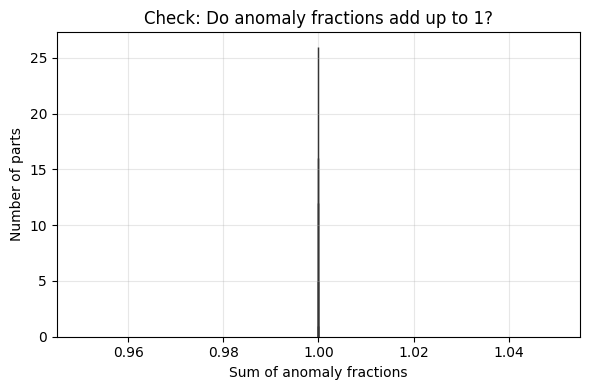

In [6]:
df["fraction_sum"] = df[feature_cols].sum(axis=1)

print("Fraction sum summary:")
display(df["fraction_sum"].describe())

display(df[["part_id", "fraction_sum"]].head())

## 7. Visualize anomaly feature distributions

Before clustering, look at how the anomaly features vary across printed parts.

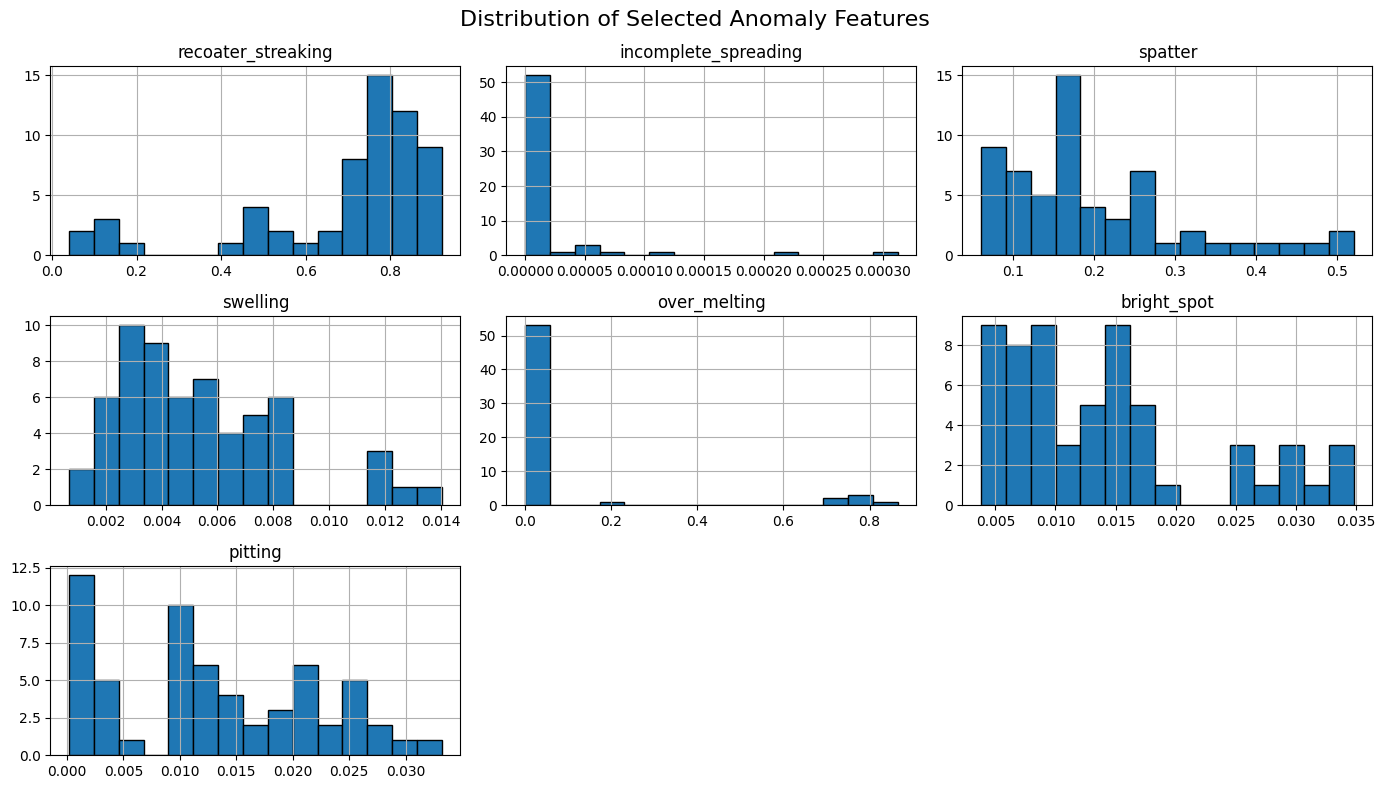

In [7]:
df[feature_cols].hist(figsize=(14, 8), bins=15, edgecolor="black")
plt.suptitle("Distribution of Selected Anomaly Features", fontsize=16)
plt.tight_layout()
plt.show()

## 8. Visualize anomaly feature correlation

This helps us see which anomaly features tend to increase or decrease together.

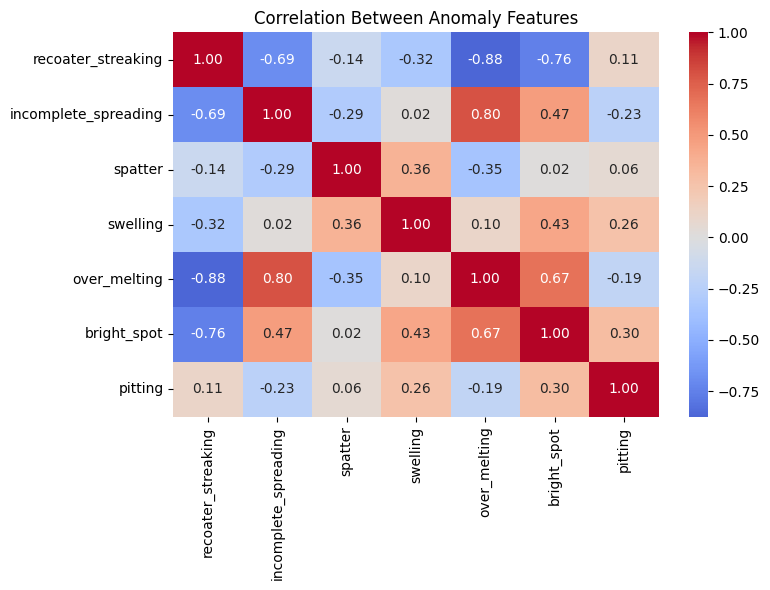

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[feature_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between Anomaly Features")
plt.tight_layout()
plt.show()

## 9. Select input features for unsupervised learning

For PCA and K-means, we do **not** use:

- `part_id`
- `parameter_set`
- `log10_fatigue_life`
- `life_class_name`

We use only anomaly feature columns.

In [9]:
X = df[feature_cols].copy()

print("Feature matrix shape:", X.shape)
display(X.head())

Feature matrix shape: (60, 7)


,recoater_streaking,incomplete_spreading,spatter,swelling,over_melting,bright_spot,pitting
0,0.113983,0.000056,0.079001,0.007600,0.758372,0.030992,0.009995
1,0.791582,0.000001,0.169361,0.003382,0.000000,0.018874,0.016800
2,0.812493,0.000000,0.152968,0.003136,0.000000,0.012357,0.019046
3,0.765535,0.000000,0.192272,0.004514,0.000000,0.015069,0.022610
4,0.777960,0.000000,0.175218,0.004686,0.000000,0.016918,0.025218


## 10. Scale the features

K-means and PCA are sensitive to feature scale.  
Even though the features are fractions, their ranges can still be different, so we standardize them.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (60, 7)


## 11. Apply PCA for 2D visualization

PCA compresses the 7 anomaly features into 2 components so we can visualize the parts.

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by first 2 PCs:")
print(pca.explained_variance_ratio_.sum())

display(df[["part_id", "PCA1", "PCA2"]].head())

Explained variance ratio:
[0.46383825 0.25146814]

Total variance explained by first 2 PCs:
0.7153063980644356


,part_id,PCA1,PCA2
0,2,4.335226,-0.230878
1,3,-0.400560,-0.049758
2,4,-0.812861,-0.275194
3,5,-0.524402,0.458915
4,6,-0.443988,0.599765


## 12. Visualize the PCA projection

Each point is one printed part.  
Parts that appear close together have similar anomaly-feature patterns.

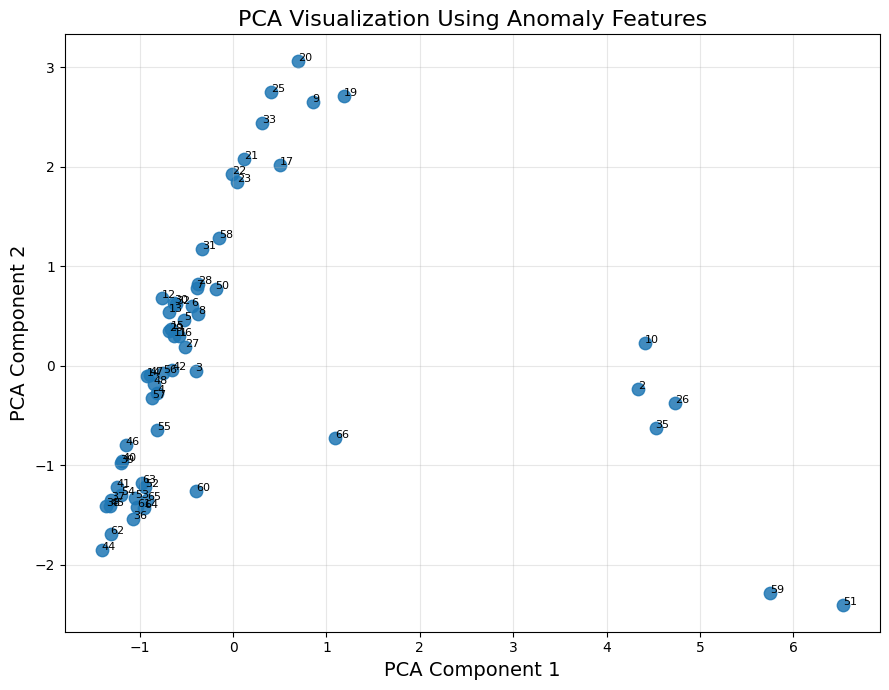

In [12]:
plt.figure(figsize=(9, 7))

plt.scatter(
    df["PCA1"],
    df["PCA2"],
    alpha=0.85,
    s=80
)

for _, row in df.iterrows():
    plt.text(
        row["PCA1"],
        row["PCA2"],
        str(int(row["part_id"])),
        fontsize=8
    )

plt.xlabel("PCA Component 1", fontsize=14)
plt.ylabel("PCA Component 2", fontsize=14)
plt.title("PCA Visualization Using Anomaly Features", fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Choose the number of clusters

K-means requires us to choose `k`, the number of clusters.

We compare different `k` values using:

- **Elbow method:** checks cluster compactness
- **Silhouette score:** checks how well-separated the clusters are

A higher silhouette score usually means cleaner cluster separation.

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)

inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_labels = kmeans.fit_predict(X_scaled)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, cluster_labels))

k_summary = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_values,
    "silhouette_score": silhouette_values
})

display(k_summary)

,k,inertia,silhouette_score
0,2,243.291377,0.587429
1,3,167.321724,0.420141
2,4,126.681845,0.367588
3,5,104.657605,0.392496
4,6,86.695910,0.390258
5,7,69.042443,0.385760
6,8,55.416939,0.407230


## 14. Plot elbow curve and silhouette score

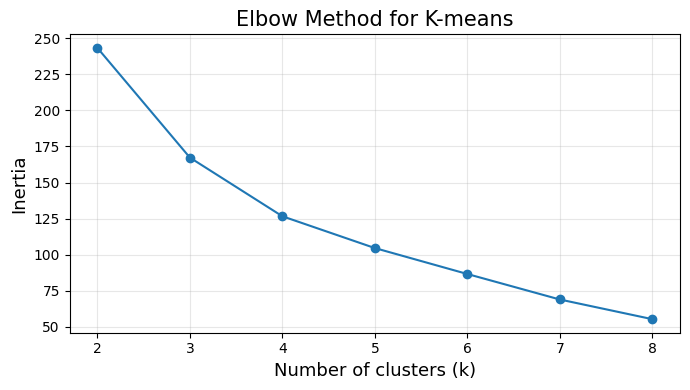

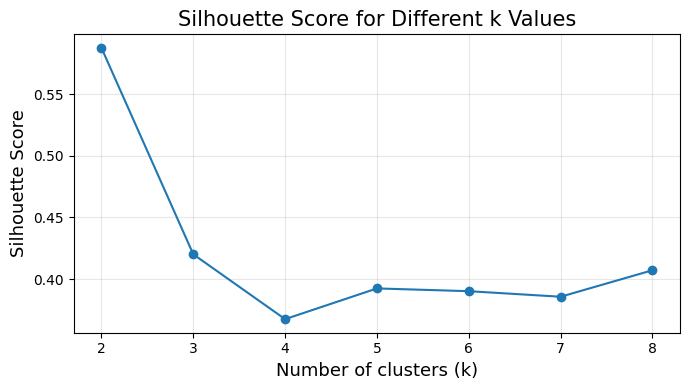

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(k_summary["k"], k_summary["inertia"], marker="o")
plt.xlabel("Number of clusters (k)", fontsize=13)
plt.ylabel("Inertia", fontsize=13)
plt.title("Elbow Method for K-means", fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k_summary["k"], k_summary["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Silhouette Score for Different k Values", fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Apply K-means clustering

Based on the PCA plot and silhouette score, we use `k = 2` for a simple and interpretable result.

In [15]:
best_k = 2

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df["cluster"].value_counts().sort_index())

display(df[["part_id", "cluster"]].head())

Cluster counts:
cluster
0     6
1    54
Name: count, dtype: int64


,part_id,cluster
0,2,0
1,3,1
2,4,1
3,5,1
4,6,1


## 16. Visualize clusters in PCA space

This plot shows the same PCA projection, but now points are colored by K-means cluster.

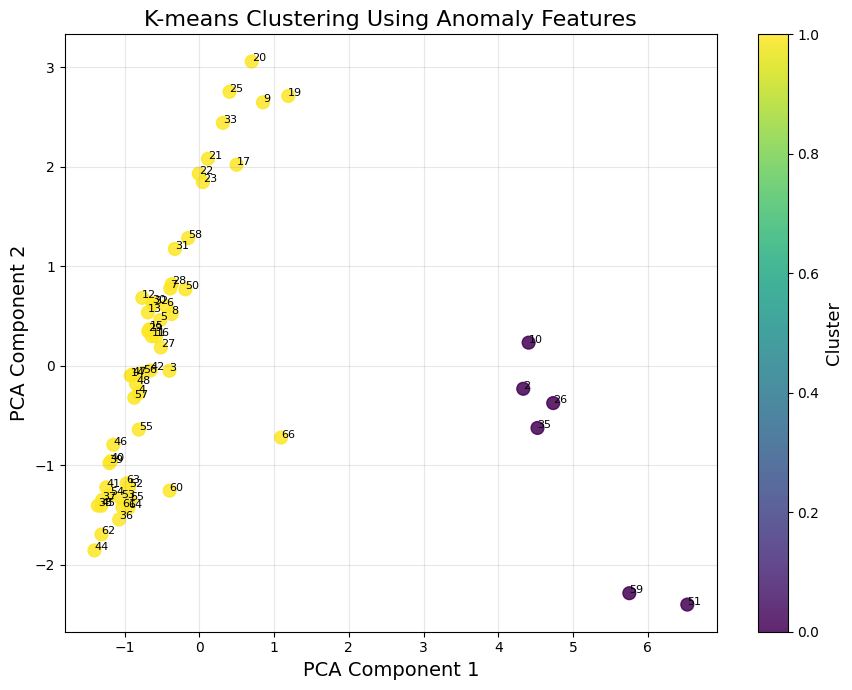

In [16]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["cluster"],
    alpha=0.85,
    s=85,
    cmap="viridis"
)

for _, row in df.iterrows():
    plt.text(
        row["PCA1"],
        row["PCA2"],
        str(int(row["part_id"])),
        fontsize=8
    )

plt.xlabel("PCA Component 1", fontsize=14)
plt.ylabel("PCA Component 2", fontsize=14)
plt.title("K-means Clustering Using Anomaly Features", fontsize=16)

cbar = plt.colorbar(scatter)
cbar.set_label("Cluster", fontsize=13)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Interpret the clusters using anomaly profiles

Unsupervised learning does not automatically name the clusters.  
We interpret them by checking the average anomaly feature values inside each cluster.

,recoater_streaking,incomplete_spreading,spatter,swelling,over_melting,bright_spot,pitting
cluster,,,,,,,
0,0.102461,0.000136,0.077276,0.006474,0.774338,0.030897,0.008419
1,0.752513,0.000002,0.212646,0.005151,0.004156,0.012160,0.013372


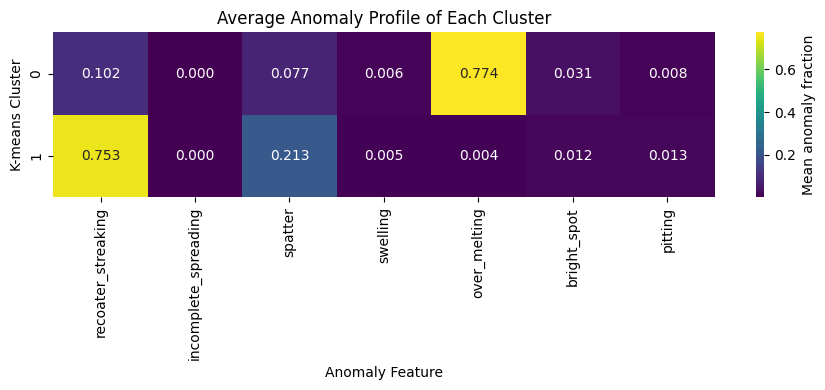

In [17]:
cluster_profile = (
    df
    .groupby("cluster")[feature_cols]
    .mean()
)

display(cluster_profile)

plt.figure(figsize=(9, 4))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={"label": "Mean anomaly fraction"}
)

plt.xlabel("Anomaly Feature")
plt.ylabel("K-means Cluster")
plt.title("Average Anomaly Profile of Each Cluster")
plt.tight_layout()
plt.show()

## 18. Readable cluster summary

In [18]:
for cluster_id in sorted(df["cluster"].unique()):
    print("=" * 60)
    print(f"Cluster {cluster_id}")
    print("Number of parts:", (df["cluster"] == cluster_id).sum())

    cluster_means = (
        df[df["cluster"] == cluster_id][feature_cols]
        .mean()
        .sort_values(ascending=False)
    )

    print(cluster_means)

Cluster 0
Number of parts: 6
over_melting            0.774338
recoater_streaking      0.102461
spatter                 0.077276
bright_spot             0.030897
pitting                 0.008419
swelling                0.006474
incomplete_spreading    0.000136
dtype: float64
Cluster 1
Number of parts: 54
recoater_streaking      0.752513
spatter                 0.212646
pitting                 0.013372
bright_spot             0.012160
swelling                0.005151
over_melting            0.004156
incomplete_spreading    0.000002
dtype: float64


## 19. Post-hoc interpretation: compare clusters with process parameters

Now we use the post-hoc columns.

Important:

> `parameter_set` was not used during clustering.  
> We use it now only to interpret what the clusters represent.

Because this notebook keeps only fatigue-tested parts, the process parameters should mainly be `parameter_set = 1` and `parameter_set = 2`.

parameter_set,1,2
cluster,,
0,0,6
1,54,0


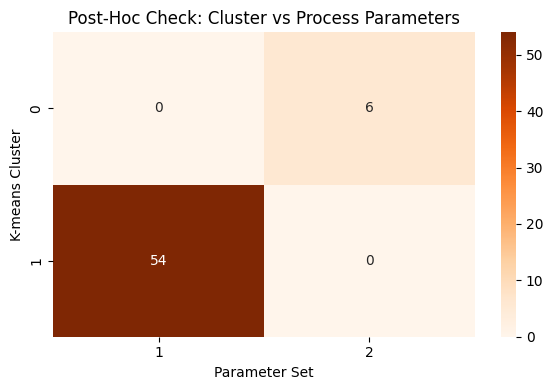

Unique parameter sets in this fatigue-tested subset: [np.int64(1), np.int64(2)]


In [26]:
if "parameter_set" in df.columns:
    cluster_recipe_table = pd.crosstab(
        df["cluster"],
        df["parameter_set"]
    )

    display(cluster_recipe_table)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cluster_recipe_table,
        annot=True,
        fmt="d",
        cmap="Oranges"
    )

    plt.xlabel("Parameter Set")
    plt.ylabel("K-means Cluster")
    plt.title("Post-Hoc Check: Cluster vs Process Parameters")
    plt.tight_layout()
    plt.show()

    print("Unique parameter sets in this fatigue-tested subset:", sorted(df["parameter_set"].dropna().unique()))
else:
    print("parameter_set column is not available.")


## 20. Post-hoc interpretation: compare clusters with fatigue-life class

Fatigue-life labels are also not used during clustering.  
Here we check whether anomaly-based clusters are related to short-life or long-life groups.

life_class_name,Long life,Short life
cluster,,
0,2,4
1,28,26


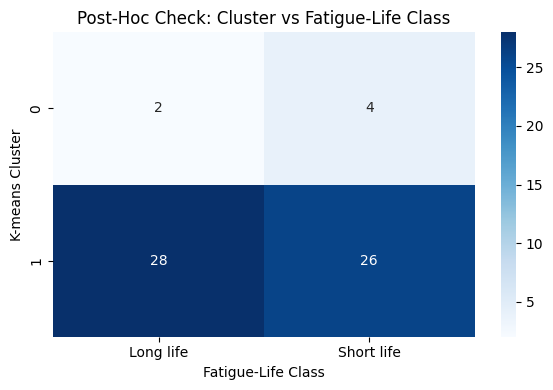

In [20]:
if "life_class_name" in df.columns:
    df_labeled = df.dropna(subset=["life_class_name"]).copy()

    cluster_life_table = pd.crosstab(
        df_labeled["cluster"],
        df_labeled["life_class_name"]
    )

    display(cluster_life_table)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cluster_life_table,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel("Fatigue-Life Class")
    plt.ylabel("K-means Cluster")
    plt.title("Post-Hoc Check: Cluster vs Fatigue-Life Class")
    plt.tight_layout()
    plt.show()
else:
    print("life_class_name column not found.")

## 21. Fatigue-life distribution by anomaly cluster

This plot uses the measured fatigue-life values after clustering.

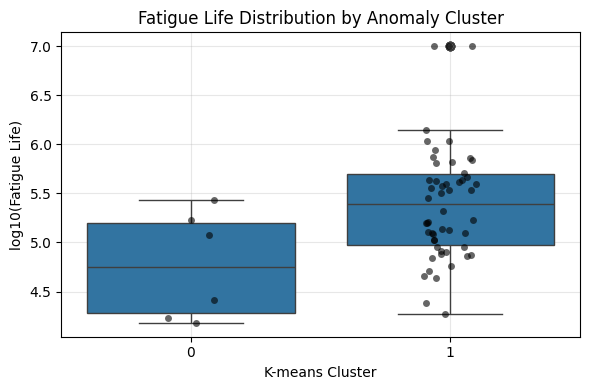

,count,mean,std,min,median,max
cluster,,,,,,
0,6,4.762112,0.548535,4.180699,4.746861,5.431048
1,54,5.427219,0.624543,4.274227,5.387800,7.000217


In [21]:
if "log10_fatigue_life" in df.columns:
    df_fatigue = df.dropna(subset=["log10_fatigue_life"]).copy()

    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=df_fatigue,
        x="cluster",
        y="log10_fatigue_life"
    )

    sns.stripplot(
        data=df_fatigue,
        x="cluster",
        y="log10_fatigue_life",
        color="black",
        alpha=0.6
    )

    plt.xlabel("K-means Cluster")
    plt.ylabel("log10(Fatigue Life)")
    plt.title("Fatigue Life Distribution by Anomaly Cluster")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fatigue_summary = (
        df_fatigue
        .groupby("cluster")["log10_fatigue_life"]
        .agg(["count", "mean", "std", "min", "median", "max"])
    )

    display(fatigue_summary)
else:
    print("log10_fatigue_life column not found.")

## 22. PCA plot colored by fatigue-life class

This is another post-hoc check.  
PCA and K-means used only anomaly features, but now we color the points by fatigue-life class.

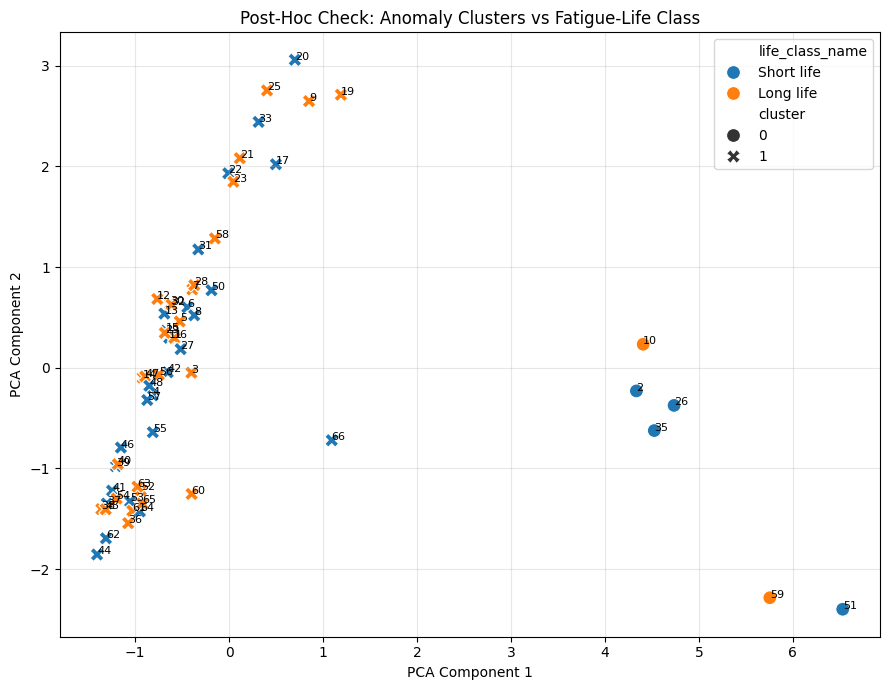

In [22]:
if "life_class_name" in df.columns:
    df_labeled = df.dropna(subset=["life_class_name"]).copy()

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        data=df_labeled,
        x="PCA1",
        y="PCA2",
        hue="life_class_name",
        style="cluster",
        s=100
    )

    for _, row in df_labeled.iterrows():
        plt.text(
            row["PCA1"],
            row["PCA2"],
            str(int(row["part_id"])),
            fontsize=8
        )

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("Post-Hoc Check: Anomaly Clusters vs Fatigue-Life Class")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("life_class_name column not found.")

## 23. Correlation with fatigue life

This is a post-experiment check:

> Are any anomaly features linearly related to fatigue life?

A correlation close to +1 or -1 indicates a stronger relationship.  
A value near 0 indicates a weak linear relationship.

,Spearman correlation with fatigue life
over_melting,-0.248945
bright_spot,-0.216118
swelling,-0.179297
pitting,-0.127609
incomplete_spreading,-0.106141
recoater_streaking,-0.012144
spatter,0.376851


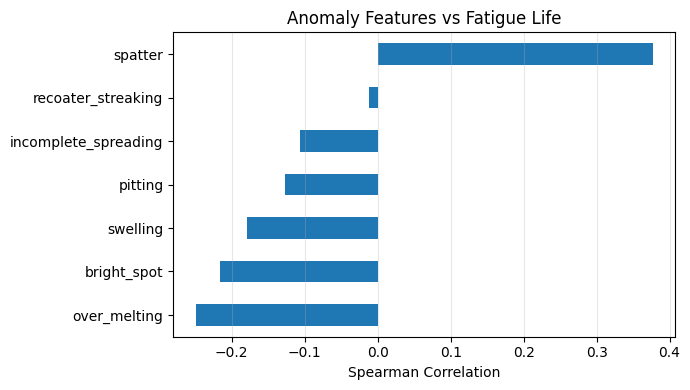

In [23]:
if "log10_fatigue_life" in df.columns:
    df_corr = df.dropna(subset=["log10_fatigue_life"]).copy()

    corr_values = (
        df_corr[feature_cols + ["log10_fatigue_life"]]
        .corr(method="spearman")["log10_fatigue_life"]
        .drop("log10_fatigue_life")
        .sort_values()
    )

    display(corr_values.to_frame(name="Spearman correlation with fatigue life"))

    plt.figure(figsize=(7, 4))
    corr_values.plot(kind="barh")
    plt.xlabel("Spearman Correlation")
    plt.title("Anomaly Features vs Fatigue Life")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("log10_fatigue_life column not found.")

## 24. Final interpretation

A good result statement should be careful and realistic.

Example:

> K-means found two groups using only anomaly features from the 60 fatigue-tested parts. One group was dominated by over-melting, while the other was dominated by recoater streaking and spatter. After clustering, we compared the groups with process parameters and fatigue-life labels. The clusters strongly matched process parameters, while fatigue life showed a weaker but meaningful trend.

This is useful because it shows how unsupervised learning can discover process behavior patterns without using labels during training.

## 25. Reflection questions

Answer these in a few sentences:

1. What does each row in the dataset represent?
2. What does an anomaly fraction mean?
3. Why do we not use fatigue-life labels during PCA or K-means?
4. How did you choose the number of clusters?
5. What anomaly pattern dominates each cluster?
6. Did the clusters relate more strongly to process parameters or fatigue-life class?
7. What is the difference between unsupervised learning and supervised learning?